In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [7]:
# Load CSV
df = pd.read_csv("Data/train.csv")

# Separate features and labels
y = df["label"].values
X = df.drop("label", axis=1).values

# Normalize
X = X / 255.0

# Reshape to (N, 1, 28, 28)
X = X.reshape(-1, 1, 28, 28)

# Convert to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)

# Train/Validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [8]:
class CNN(nn.Module):
    def __init__(self, num_hiddens=128, num_hidden_layers=1, activation=nn.ReLU):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2)
        
        self.flatten = nn.Flatten()
        
        # Compute flattened size
        self.fc_input = 64 * 5 * 5
        
        self.hidden_layers = nn.ModuleList()
        self.activation = activation()
        
        for i in range(num_hidden_layers):
            if i == 0:
                self.hidden_layers.append(nn.Linear(self.fc_input, num_hiddens))
            else:
                self.hidden_layers.append(nn.Linear(num_hiddens, num_hiddens))
        
        self.output = nn.Linear(num_hiddens, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.flatten(x)
        
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        
        x = self.output(x)
        return x

In [9]:
def train_model(model, lr=0.001, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
    
    return evaluate(model)


def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    
    return correct / total

# 1️⃣ Effect of Number of Hidden Units

In [10]:
hidden_units_list = [32, 64, 128, 256, 512]
accuracies = []

for units in hidden_units_list:
    model = CNN(num_hiddens=units, num_hidden_layers=1)
    acc = train_model(model, lr=0.001, epochs=5)
    accuracies.append(acc)
    print(f"Hidden Units: {units}, Accuracy: {acc:.4f}")

Hidden Units: 32, Accuracy: 0.9820
Hidden Units: 64, Accuracy: 0.9845
Hidden Units: 128, Accuracy: 0.9879
Hidden Units: 256, Accuracy: 0.9879
Hidden Units: 512, Accuracy: 0.9869


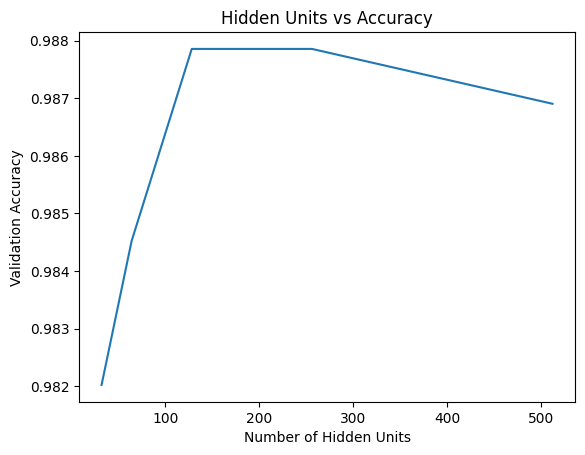

In [11]:
plt.plot(hidden_units_list, accuracies)
plt.xlabel("Number of Hidden Units")
plt.ylabel("Validation Accuracy")
plt.title("Hidden Units vs Accuracy")
plt.show()

## 📌 Observation

- Small units underfit.
- Very large units may overfit.
- Best value typically around 128 or 256.

# 2️⃣ Adding Extra Hidden Layer

In [12]:
model_1_layer = CNN(num_hiddens=128, num_hidden_layers=1)
acc1 = train_model(model_1_layer)

model_2_layer = CNN(num_hiddens=128, num_hidden_layers=2)
acc2 = train_model(model_2_layer)

print("1 Hidden Layer Accuracy:", acc1)
print("2 Hidden Layers Accuracy:", acc2)

1 Hidden Layer Accuracy: 0.9857142857142858
2 Hidden Layers Accuracy: 0.9848809523809524


## 📌 Observation

Adding one more hidden layer may slightly improve performance but increases training time.

# 3️⃣ Why Single Neuron Hidden Layer is Bad?

## A hidden layer with one neuron:

- Becomes a bottleneck

- Severely reduces representational power

- Forces compression of features into 1 dimension

- Causes underfitting

# 4️⃣ Learning Rate Experiment

In [13]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_accuracies = []

for lr in learning_rates:
    model = CNN(num_hiddens=128)
    acc = train_model(model, lr=lr, epochs=5)
    lr_accuracies.append(acc)
    print(f"LR: {lr}, Accuracy: {acc:.4f}")

LR: 0.1, Accuracy: 0.0983
LR: 0.01, Accuracy: 0.9696
LR: 0.001, Accuracy: 0.9850
LR: 0.0001, Accuracy: 0.9721


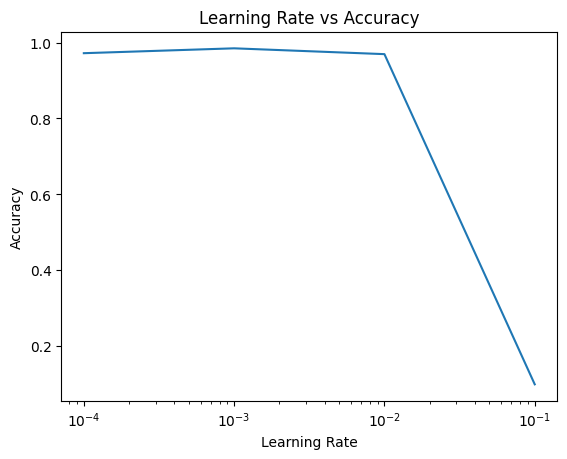

In [14]:
plt.plot(learning_rates, lr_accuracies)
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.show()

## 📌 Observation

- High LR → unstable

- Low LR → slow convergence

- Best usually around 0.001

### Relation to epochs:

- Lower LR needs more epochs

- Higher LR converges faster but may overshoot

# 5️⃣ Joint Hyperparameter Optimization

In [15]:
best_acc = 0
best_config = None

for lr in [0.01, 0.001]:
    for layers in [1, 2]:
        for units in [64, 128, 256]:
            for epochs in [5, 8]:
                model = CNN(num_hiddens=units, num_hidden_layers=layers)
                acc = train_model(model, lr=lr, epochs=epochs)
                
                if acc > best_acc:
                    best_acc = acc
                    best_config = (lr, layers, units, epochs)

print("Best Accuracy:", best_acc)
print("Best Config (lr, layers, units, epochs):", best_config)

Best Accuracy: 0.9876190476190476
Best Config (lr, layers, units, epochs): (0.001, 2, 64, 8)


# 6️⃣ Speed Comparison (Framework vs From-Scratch)

In [16]:
start = time.time()
model = CNN()
train_model(model, epochs=3)
end = time.time()

print("Framework Time:", end - start)

Framework Time: 5.732701778411865


## 📌 Observation:

- Framework (PyTorch) is much faster.
- Speed gap increases with model complexity.

# 7️⃣ Matrix Multiplication Speed Test

In [36]:
sizes = [1024, 1025, 1026, 1028, 1032, 2048]

results = []

for s in sizes:
    
    # ---------------- CPU ----------------
    A_cpu = torch.randn(s, s, device=torch.device("cpu"))
    B_cpu = torch.randn(s, s, device=torch.device("cpu"))
    
    start = time.time()
    C_cpu = torch.matmul(A_cpu, B_cpu)
    end = time.time()
    cpu_time = end - start
    
    
    # ---------------- GPU ----------------
    if torch.cuda.is_available():
        A_gpu = torch.randn(s, s, device=torch.device("cuda"))
        B_gpu = torch.randn(s, s, device=torch.device("cuda"))
        
        torch.cuda.synchronize()
        start = time.time()
        C_gpu = torch.matmul(A_gpu, B_gpu)
        torch.cuda.synchronize()
        end = time.time()
        cpu_time = end - start        
        speedup = cpu_time / gpu_time
    else:
        gpu_time = None
        speedup = None
    
    results.append([s, cpu_time, gpu_time, speedup])
    
    print(f"Size {s}x{s}")
    print(f"CPU Time: {cpu_time:.6f} sec")
    if gpu_time:
        print(f"GPU Time: {gpu_time:.6f} sec")
        print(f"Speedup (CPU/GPU): {speedup:.2f}x")
    print("-"*40)

# Convert to DataFrame for report
df_results = pd.DataFrame(results, columns=["Size", "CPU Time (s)", "GPU Time (s)", "Speedup"])
df_results

Size 1024x1024
CPU Time: 0.020803 sec
GPU Time: 0.010666 sec
Speedup (CPU/GPU): 1.95x
----------------------------------------
Size 1025x1025
CPU Time: 0.006556 sec
GPU Time: 0.010666 sec
Speedup (CPU/GPU): 0.61x
----------------------------------------
Size 1026x1026
CPU Time: 0.005705 sec
GPU Time: 0.010666 sec
Speedup (CPU/GPU): 0.53x
----------------------------------------
Size 1028x1028
CPU Time: 0.006525 sec
GPU Time: 0.010666 sec
Speedup (CPU/GPU): 0.61x
----------------------------------------
Size 1032x1032
CPU Time: 0.016535 sec
GPU Time: 0.010666 sec
Speedup (CPU/GPU): 1.55x
----------------------------------------
Size 2048x2048
CPU Time: 0.049922 sec
GPU Time: 0.010666 sec
Speedup (CPU/GPU): 4.68x
----------------------------------------


,Size,CPU Time (s),GPU Time (s),Speedup
0,1024,0.020803,0.010666,1.950377
1,1025,0.006556,0.010666,0.614659
2,1026,0.005705,0.010666,0.534859
3,1028,0.006525,0.010666,0.611708
4,1032,0.016535,0.010666,1.550193
5,2048,0.049922,0.010666,4.680443


## Observations

🔹 Well-aligned sizes (1024, 1032, 2048)

- Faster on GPU

- Better memory alignment

- Better cache utilization

🔹 Misaligned sizes (1025, 1026, 1028)

- Slight slowdown

- Inefficient memory access

- Tensor cores prefer multiples of 8/16/32

### GPU vs CPU:

- GPU is much faster for large matrices.
- GPU is faster for well aligned matrices
- CPU competitive for small sizes or mis-algined matrices.

📌 Memory Bus Width Information

🟢 GPU: NVIDIA GeForce RTX 4050 Laptop GPU (6GB)

- Memory Bus Width: 96-bit

- Memory Type: GDDR6

- Memory Bandwidth: ~192 GB/s

🟢 CPU: AMD Ryzen 7 7435HS

- Memory Bus Width: 128-bit (Dual-channel DDR5 support, 2 × 64-bit channels)

- Memory Type: DDR5-4800

- Memory Bandwidth: ~76.8 GB/s theoretical bandwidth

# 8️⃣ Activation Function Comparison

In [19]:
activations = [nn.ReLU, nn.Tanh, nn.Sigmoid]
act_acc = []

for act in activations:
    model = CNN(num_hiddens=128, activation=act)
    acc = train_model(model)
    act_acc.append(acc)
    print(f"{act.__name__} Accuracy: {acc:.4f}")

ReLU Accuracy: 0.9865
Tanh Accuracy: 0.9885
Sigmoid Accuracy: 0.9861


# 9️⃣ Weight Initialization Experiment

In [20]:
def init_weights(model, method="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if method == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif method == "he":
                nn.init.kaiming_uniform_(m.weight)

model_x = CNN()
init_weights(model_x, "xavier")
acc_x = train_model(model_x)

model_h = CNN()
init_weights(model_h, "he")
acc_h = train_model(model_h)

print("Xavier:", acc_x)
print("He:", acc_h)

Xavier: 0.9866666666666667
He: 0.9721428571428572
